# GO proposal for AGN

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from astropy.coordinates import SkyCoord
from ipywidgets import *
from tqdm import tqdm
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

# PlatoSim libraries
# import platosim.smbhb     as bh
import platosim.slurm     as sm
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [7]:
# Paths to where data is stored
hdir = ut.getHomeDir('inputfiles/data_picsim')
path = ut.getWorkDir('smbhb')
idir = path / 'input'
ddir = path / 'data'
sdir = path / 'simulations'
gdir = path / 'godata'
fdir = Path('/lhome/nicholas/Nextcloud/latex/proposals/plato_GO_AO-1_AGN')
# fdir = path / 'figures'

In [4]:
# Load PIC LOSP2 catalogue
dc = pd.read_feather(hdir / 'PlatoGO_PIC210_LOPS2.ftr')

---
## 1. Target list
---

### Load AGN catalogue queried from Simbad

Sources:
- [Simbad criteria query](https://simbad.cds.unistra.fr/simbad/sim-fsam)
- [Simbad otype classes for AGN](https://simbad.cds.unistra.fr/guide/otypes.htx)
- [Gaia single-source search](https://gaia.ari.uni-heidelberg.de/singlesource.html)

We used the following Simbad query:
```
otype='AGN'  & Vmag <  16   &
ra   >  46.5 & ra  <  144.5 & 
dec  > -78.5 & dec <  -17.5 &
```

<IPython.core.display.Javascript object>


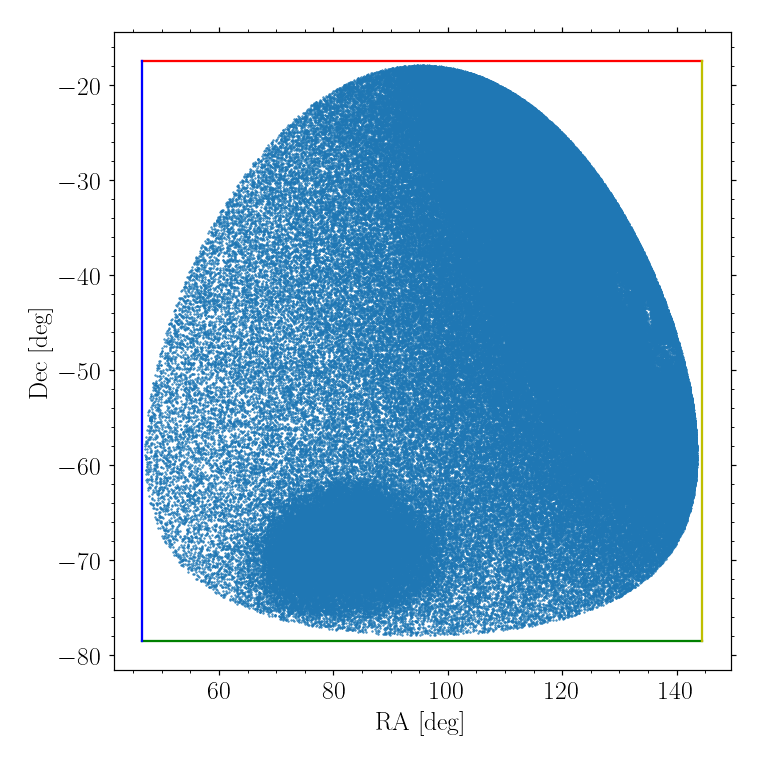

In [6]:
# Plot Simbad criterion limits
ra_min  = 46.5 
ra_max  = 144.5 
dec_min = -78.5 
dec_max = -17.5
dx = dc.copy().iloc[::100]
plt.figure(figsize=(7,7))
plt.plot(dx.ra, dx.dec, '.', ms=1)
plt.plot([ra_min, ra_max], [dec_min, dec_min], 'g-')
plt.plot([ra_min, ra_max], [dec_max, dec_max], 'r-')
plt.plot([ra_min, ra_min], [dec_min, dec_max], 'b-')
plt.plot([ra_max, ra_max], [dec_min, dec_max], 'y-')
plt.xlabel('RA [deg]')
plt.ylabel('Dec [deg]')
plt.tight_layout();

In [212]:
# Load the dataset from the Simbad query
df_gal = pd.read_csv(ddir / 'table_Simbad_Galaxy.csv')

# Change coordinates to deg
for i in range(df_gal.shape[0]):
    dx = df_gal.iloc[i]
    coor = SkyCoord(ra=dx.ra, dec=dx.dec,unit=(u.hourangle, u.deg))
    df_gal.ra.iloc[i]  = coor.ra.deg
    df_gal.dec.iloc[i] = coor.dec.deg

# Strip white-space from name column
df_gal.name = df_gal.name.str.strip()

#Sort values after magnitude
df_gal = df_gal.sort_values(by='Vmag').reset_index(drop=True)
df_gal
#--------------------------------------------
# otype = 'EmG'
# # print(df_gal.otype.unique())
# dx = df_gal[df_gal.otype == otype].reset_index(drop=True).iloc[0]
# print(dx['name'], dx.ra, dx.dec)
# fig, ax = pt.plotPlatoFOV(
#     'LOPS2', system='galactic', ncamStars=True, fovSize=30,
#     raStars=dx.ra, decStars=dx.dec, c=dx.Vmag, 
#     clabel=r'$\mathcal{P}$ [mag]', s=300, lw=0.5, ec='k',
#     figsize=(9,9));

,name,otype,ra,dec,Umag,Bmag,Vmag,Rmag,Imag
0,AM 0311-513,G,48.25,-51.3,,6.9,7.800000,,
1,NGC 1316,rG,50.674121,-37.2082,9.81,9.15,8.530000,7.66,
2,NGC 1269,EmG,49.327408,-41.10795,9.85,9.83,8.810000,8.72,
3,NGC 1553,GiP,64.043621,-55.780019,10.76,10.10,9.400000,8.74,
4,NGC 1365,Sy1,53.401908,-36.140658,10.48,10.08,9.630000,8.79,9.7
...,...,...,...,...,...,...,...,...,...
253,EC 04028-5412,AG?,61.005175,-54.064839,16.57,16.71,16.710000,,NaN
254,LEDA 74592,EmG,52.580279,-52.5183,,17.27,16.790000,16.45,
255,2MASX J03322988-2744244,EmG,53.124504,-27.740283,19.55,17.6891,16.891000,16.74,16.467
256,2MASX J03091681-4126222,EmG,47.319921,-41.439489,,17.8,16.900000,,


In [213]:
galaxies = [
    #---------- EmG
    6,  200, 'Gaia DR3 4682184230100236928', 'NGC 1543',                0.00391469862121995, # type -1.8
    6,  200, 'Gaia DR3 4682608675948630656', 'NGC 1533',                0.00264733319281051, # type -2.0
    12, 180, 'Gaia DR3 4778632260511770880', 'NGC 1546',                0.00427207436339927, # type -1.0
    12, 540, 'Gaia DR3 4779841276625379712', 'NGC 1515',                0.003922065898,      # type, 3.0, 2x5 imagettes
    12, 180, 'Gaia DR3 5267762579499072768', 'NGC 2434',                0.004683,            # ellip, E0-1
    12, 300, 'Gaia DR3 2886589765219489792', 'NGC 2188',                0.00248848233592635, #type=Sm
    6,  240, 'Gaia DR3 4827649760190224896', 'MCG-05-13-011',           0.00325454385120815, # type 8.0
    6,  120, 'Gaia DR3 4875289331278097920', 'NGC 1800',                0.00271957689871893, # type 9
    6,   40, 'Gaia DR3 4867469845100665984', 'LEDA 100592',             0.0597,              # spiral, S0
    6,  180, 'Gaia DR3 4682587304191364992', 'NGC 1536',                0.0043792785960588,  # spiral, SB(s)cpec?
    12, 100, 'Gaia DR3 2898562794012526976', 'MCG-05-15-009',           0.02236547258303609, # type -3.5
    12, 120, 'Gaia DR3 4780387905703181056', 'NGC 1522',                0.00303102055750614, # typeS0
    12, 150, 'Gaia DR3 2909444694948104960', 'MCG-05-15-002',           0.00463024864126015, # type 6.7
    6,   70, 'Gaia DR3 4657456114826746624', 'NGC 2150',                0.01501773163489739, # type 2.0
    12, 120, 'Gaia DR3 4779520318014377216', 'IC 2032',                 0.00356280714022338, # type 10, low surface brightness!
    6,   40, 'Gaia DR3 4651517996104218880', '2MASS J05144786-7210339', 0.02551098200075467, # Side-view
    6,   20, 'Gaia DR3 4657496728032368000', 'LEDA 3704836',            0.03720573917840188, # heavily contaminated
    6,   70, 'Gaia DR3 4682099400202230912', 'ESO 118-19',              0.00413285913950510, # type -1.0
    6,  120, 'Gaia DR3 4867020763319548416', 'LEDA 132286',             0.05965793842618949, # type Sc, RA/Dec offset -> nearby galaxy!
    #---------- G
    6,   30, 'Gaia DR3 4656785550168125056', 'GH 9-5',                  0,                   #  
    12,  30, 'Gaia DR3 4790403116604525440', 'LEDA 88351',              0.04706255819150727, # blob
    12,  35, 'Gaia DR3 5282816061921556352', '2MASX J06004328-6840104', 0.03844802039314166, # blob, SBb
    6,   30, 'Gaia DR3 5278637883389153920', '2MASX J06103555-7020514', 0.02627295517756778, # blob
    18,  50, 'Gaia DR3 4758875067354276992', '2MASX J05545691-6000478', 0.04993788069211535, # spiral, very bright nucleus
    6,   50, 'Gaia DR3 2908445376320359168', 'ESO 487-22',              0.00005580683032779, # spiral
    12,  50, 'Gaia DR3 4779756339354066432', 'LEDA 14406',              0.04455161645491246, # spiral, S0, bright nucleus
    24,  50, 'Gaia DR3 5495096680239697024', 'LEDA 148842',             0.03275932978941051, # spiral
    6,   40, 'Gaia DR3 4653143344889019648', 'GH 1-16',                 0,                   # spiral, SBb
    6,   30, 'Gaia DR3 4656903782037390208', 'GH 9-6',                  0,                   # spiral, Sc
    12,  30, 'Gaia DR3 4664234153020223616', 'GH 8-7',                  0,                   # spiral
    24,  25, 'Gaia DR3 4802112365684697088', 'LEDA 147930',             0.05177581885665716, # spiral
    6,   25, 'Gaia DR3 2908276154608140928', 'LEDA 3699613',            0.03522436845292485, # blob
    12,  35, 'Gaia DR3 4659042465275554560', 'GH 10-1',                 0,                   # spiral, Sb
    6,   20, 'Gaia DR3 4653907612830000640', 'GH 1-4',                  0,                   # blob
    6,   15, 'Gaia DR3 4663635438902448384', 'GH 7-19',                 0,                   # blob
    6,   50, 'Gaia DR3 4649824920004751360', 'ESO 33-3',                0.02551431764170665, # blob
#     12,  15, 'Gaia DR3 4812006561584970496', '6dFGS gJ045614.0-423123', 0.00009071687046446, # blob, heavily contaminated!
    6,   20, 'Gaia DR3 4653920910048769280', 'GH 1-2',                  0,                   # blob 
    6,   30, 'Gaia DR3 4656919312639378048', 'GH 9-4',                  0,                   # spiral, Sb, side-view
    6,   20, 'Gaia DR3 4664205673099855744', 'GH 8-6',                  0,                   # blob
    6,   20, 'Gaia DR3 4664140080365377536', 'GH 8-10',                 0,                   # blob
    6,   20, 'Gaia DR3 4664166949679691648', 'GH 8-3',                  0,                   # blob
    6,   30, 'Gaia DR3 4653192277439350400', 'GH 1-8',                  0,                   # spiral, SBc
#     6,   15, 'Gaia DR3 4663659318892318976', 'GH 7-15',                 0,                   # blob, crowded region!
    6,   20, 'Gaia DR3 4653176265803455360', 'GH 1-15',                 0,                   # blob, Sa
#     6,   30, 'Gaia DR3 4656842587343485952', 'GH 9-2',                  0,                   # spiral, SBb, crowded region! 
    #---------- GiP
    12, 260, 'Gaia DR3 4778663149916408064', 'NGC 1553',                0.004026,            # type -3.0, 3x3 ima
    12, 300, 'Gaia DR3 4778669369028919808', 'NGC 1549',                0.004093,            # type -5.0, 3x3 ima
    12, 300, 'Gaia DR3 4776049297245581312', 'NGC 1617',                0.00355209498167741, # spiral, 1.0, 3x3 ima
    6,  260, 'Gaia DR3 4841932794190647680', 'NGC 1512',                0.00300659664811830, # spiral, 1.0, 3x3 ima
    12, 420, 'Gaia DR3 4779024098968883456', 'NGC 1596',                0.004983,            # type -2.0, 1x4 ima
    6,   80, 'Gaia DR3 4841557414048502528', 'NGC 1510',                0.00335461018899563, # spiral, S0, 1x1 ima
    12, 120, 'Gaia DR3 4779023205615002368', 'NGC 1602',                0.00524302880803428, # type 9.0, 1x1 ima
    12, 100, 'Gaia DR3 4779836088306553600', 'NGC 1515A',               0.04448529215646757, # spiral, 3.0, bar 
    #---------- GiG (mergers)
    6,  170, 'Gaia DR3 4676459725889776768', 'NGC 1559',                0.00433572548449467, # spiral, SB(s)cd, 2x2 ima
    12, 240, 'Gaia DR3 4778334769602793088', 'NGC 1574',                0.003439,            # type -2.5, 4x4 ima
    12, 140, 'Gaia DR3 4757235420651441280', 'NGC 1947',                0.003803,            # type -2.0, 2x2 ima
    12, 250, 'Gaia DR3 5506661240461437696', 'NGC 2427',                0.00326491815524199, # spiral, 8.0, faint, 6x4 ima
    6,  120, 'Gaia DR3 2919628436072070400', 'NGC 2272',                0.00710009953502366, # type -3.0, 2x2 ima
    6,  140, 'Gaia DR3 4761480944270070528', 'NGC 1796',                0.00338908352830591, # spiral, 6.0, 2x2 ima 
#     6,   15, 'Gaia DR3 4661384734281674880', '2MASX J05073710-6822590', 0.01878966548251190, # faint, crowded region!
    12,  50, 'Gaia DR3 4774162230349105536', 'ESO 118-34',              0.00381524570791969, # type S0
    #---------- LSB
    6,  300, 'Gaia DR3 2959227076762704000', 'NGC 1744',                0.00247677853656447, # type 7.0, 2x4 ima    
    #---------- rG
    12,  60, 'Gaia DR3 4780599870929946496', 'IC 2082',                 0.0397,    
    24,  50, 'Gaia DR3 5501007689111963648', 'PKS 0620-526',            0.0497,
    #---------- SyG
    12, 460, 'Gaia DR3 4773934047325895168', 'NGC 1672',                0.004464,
    6,   18, 'Gaia DR3 2906862560611768960', 'LEDA 2824330',            0.068,
    #---------- Sy1
    12, 520, 'Gaia DR3 4779165759875235200', 'NGC 1566',                0.00473963,
    12,  14, 'Gaia DR3 4775331664045020160', 'LB 1727',                 0.10410067,
    12,  25, 'Gaia DR3 5282115196267296256', 'FRL 265',                 0.030451,
    6,   25, 'Gaia DR3 2936769208170781952', 'LEDA 3095733',            0.03778,
    12,  20, 'Gaia DR3 4789861813285837056', 'LEDA 3095692',            0.05145175,
    24,  30, 'Gaia DR3 2883688050953797760', 'IRAS 05563-3820',         0.03310493,
    12,  12, 'Gaia DR3 4756452052971526912', '2MASS J05522451-6402108', 0.680,
    6,   15, 'Gaia DR3 4879352885736712192', '2MASS J04432078-2820520', 0.15550,
    12,  50, 'Gaia DR3 5514459900347426432', 'ESO 209-12',              0.04007455,
    6,   14, 'Gaia DR3 4893164366689421696', 'LEDA 3095695',            0.08414478,
    6,   13, 'Gaia DR3 4879651849820703488', 'LEDA 75249',              0.28581,
    6,   13, 'Gaia DR3 4663169417750643712', '2MASX J04494090-6436213', 0.0600,
    6,   13, 'Gaia DR3 4837149952970309504', '2MASS J04124148-4712461', 0.132,
    12,  19, 'Gaia DR3 4780619627780461696', 'FRL 303',                 0.039,
    6,   14, 'Gaia DR3 4867236336317793536', 'CTS 49',                  0.181,
    6,   14, 'Gaia DR3 4881212744015331840', '2MASX J04470958-2657352', 0.113812,
    24,  17, 'Gaia DR3 5505467789310281472', 'LEDA 88588',              0.04057,
    18,  18, 'Gaia DR3 4799794011057558016', 'ESO 252-18A',             0.03497470,
    24,  23, 'Gaia DR3 4791851242137483392', 'IRAS 05562-5357',         0.0967,
    6,   18, 'Gaia DR3 4761465310590509056', 'LEDA 146811',             0.0053,
    #---------- Sy2
    6,  455, 'Gaia DR3 4823508724522473472', 'NGC 1808',                0.003343,
    12, 300, 'Gaia DR3 2899383923036427008', 'NGC 2217',                0.005425,
    6,   75, 'Gaia DR3 4825962731396079744', 'ESO 362-8',               0.0158,
    6,   30, 'Gaia DR3 4675802943784869248', '1RXS J042710.2-624712',   0.018,
    12,  50, 'Gaia DR3 4826515407787798400', 'MCG-05-13-017',           0.01246008,
    6,   65, 'Gaia DR3 5606511636595211392', 'MCG-05-18-002',           0.00565999979153,
    18,  60, 'Gaia DR3 5495804903167280256', '2MASX J06002140-5756210', 0.038150,
    12,  30, 'Gaia DR3 2892805751127673728', 'IRAS 06115-3241',         0.050018,
    6,   30, 'Gaia DR3 2957793279241779328', 'IRAS 05189-2524',         0.04089978,
    24,  75, 'Gaia DR3 4799082833193329152', 'ESO 253-3',               0.04210457,
    12,  60, 'Gaia DR3 4774591246042006016', 'ESO 119-8',               0.023260,
    18,  84, 'Gaia DR3 4805199897412245376', 'ESO 306-25',              0.025001,
    12,  90, 'Gaia DR3 4778481661779060480', 'ESO 157-23',              0.04392442,
    6,   25, 'Gaia DR3 4877062259417089664', 'MCG-05-13-003',           0.0380,
    12,  70, 'Gaia DR3 5481554579636887680', 'ESO 121-28',              0.04045890,
    24,  70, 'Gaia DR3 4799287514152123904', 'ESO 253-8',               0.035214,
    6,   60, 'Gaia DR3 4866483858047537280', 'LEDA 132310',             0.041993,
    12,  30, 'Gaia DR3 5283621321042741504', '2MASX J06291339-6630029', 0.046799,
    6,   60, 'Gaia DR3 4866264986514287232', 'ESO 304-11',              0.040895,
    #---------- LIN
    6,  420, 'Gaia DR3 5267697094131487488', 'NGC 2442',                0.004846,
    6,  130, 'Gaia DR3 4788661249667522816', 'ESO 202-23',              0.016288,
    #---------- AGN
    6,   16, 'Gaia DR3 4839258610114187264', 'IRAS F04239-4416',        0.390189,             # Contaminated -> sizeDSS = 16"
#     6,   13, 'Gaia DR3 4660112947260694528', '2MASS J05344418-6737501', 1.009,                # Crowded region!
    12,  15, 'Gaia DR3 2910484283194572032', '2MASS J05542527-2805447', 0.063,                #
    6,   11, 'Gaia DR3 4665633973057748096', 'EC 04536-6121',           0.784,                #
    6,   10, 'Gaia DR3 4674156528202556160', 'EC 03271-6235',           0.348303,             #
    #---------- BLL
    24,  30, 'Gaia DR3 5554574624305070976', 'ESO 254-17',              0.037,                #
    12,  30, 'Gaia DR3 4822275862749577472', 'ESO 362-21',              0.05544933,           #
    12,  30, 'Gaia DR3 5476948725428677376', 'QSO J0623-6436',          0.12771400,           #
    24,  20, 'Gaia DR3 4794222613840578304', 'QSO B0558-5026',          0.13750813,           #
    12,  15, 'Gaia DR3 4814500219596967296', 'PKS J0449-4350',          0.107000,             #
    12,  30, 'Gaia DR3 2902608000368235904', 'PKS J0550-3216',          0.06890446,           #
    12,  15, 'Gaia DR3 5281841383512089216', '2MASS J07003124-6610452', 0.0,                  # No redshift from Simbad..
    #---------- QSO
    18,  14, 'Gaia DR3 4800195161003160960', 'HE 0515-4414',            1.713,                #
    #---------- AG? (Good IMBHs candidates)
    24, 270, 'Gaia DR3 5563918239759683328', 'NGC 2310',                0.003382,             # type -2.0
    6,  250, 'Gaia DR3 4878435132828865664', 'MCG-05-12-003',           0.004933574592300482, # spiral/irregular, diffuse,
    6,  240, 'Gaia DR3 4826905287739126528', 'MCG-06-12-010',           0.003097269242025246, # spiral/irregular, diffuse
    12,  40, 'Gaia DR3 5478093317032218496', 'ESO 87-14',               0.017226842076906612, # irregular/merger?
    12, 120, 'Gaia DR3 4774801012244763904', 'ESO 158-3',               0.004026,             # irregular/merger?, type 9.3
    6,   60, 'Gaia DR3 2959319676256276096', 'MCG-04-12-041',           0.002776104558644743, #
    12,  60, 'Gaia DR3 4780697761825915776', 'IC 2073',                 0.013327968526852807, #
    6,  300, 'Gaia DR3 4665606996366566400', 'ESO 119-16',              0.003284328433433625, # spiral, faint/diffuse
    6,   50, 'Gaia DR3 4681746869284665984', 'IC 2049',                 0.004902064610671442, #
    12,  60, 'Gaia DR3 4775726904115785984', 'ESO 157-44',              0.005370124021708333, #
    6,   40, 'Gaia DR3 4654782446138047104', 'LEDA 177823',             0.016087796311406874, #
    24,  30, 'Gaia DR3 5574700596240225920', 'LEDA 75555',              0.006,                #
    12,  14, 'Gaia DR3 4779842135620350208', 'EC 04028-5412',           0,                    #  
]
# Fetch sources within LOPS2
names = galaxies[3::5]
df_gal = pd.concat([df_gal[df_gal.name == n] for n in names])

# Add new columns
df_gal['ncam']    = galaxies[0::5]
df_gal['sizeDSS'] = galaxies[1::5]
df_gal['gaiaDR3'] = galaxies[2::5]
df_gal['z']       = galaxies[4::5]
df_gal = df_gal.reset_index(drop=True)

# Drop normal galaxies
df_gal = df_gal[df_gal.otype != 'G'].reset_index(drop=True)

# Save file
# df_gal.to_feather(ddir / 'table_galaxies_Gmag16.csv')
# df_gal

In [214]:
# Create new data frame 
df_simbad = df_gal.copy()
df_simbad = pd.DataFrame({
    'name'   : df_simbad.name,
    'gaiaDR3': df_simbad.gaiaDR3,
    'otype'  : df_simbad.otype,
    'ra'     : df_simbad.ra,
    'dec'    : df_simbad.dec,
    'Vmag'   : df_simbad.Vmag,
    'Pmag'   : df_simbad.Vmag,
    'Gmag'   : df_simbad.Vmag,
    'BP_RP'  : None,
    'SPR'    : 0,
    'NSR'    : None,
    'ncam'   : df_simbad.ncam,
    'sizeDSS': df_simbad.sizeDSS,
    'z'      : df_simbad.z,
}).reset_index(drop=True)
df_simbad

,name,gaiaDR3,otype,ra,dec,Vmag,Pmag,Gmag,BP_RP,SPR,NSR,ncam,sizeDSS,z
0,NGC 1543,Gaia DR3 4682184230100236928,EmG,63.179871,-57.737869,10.600,10.600,10.600,None,0,None,6,200,0.003915
1,NGC 1533,Gaia DR3 4682608675948630656,EmG,62.465979,-56.118447,10.920,10.920,10.920,None,0,None,6,200,0.002647
2,NGC 1546,Gaia DR3 4778632260511770880,EmG,63.652258,-56.060811,10.920,10.920,10.920,None,0,None,12,180,0.004272
3,NGC 1515,Gaia DR3 4779841276625379712,EmG,61.011154,-54.100139,11.030,11.030,11.030,None,0,None,12,540,0.003922
4,NGC 2434,Gaia DR3 2886589765219489792,EmG,113.713125,-69.284164,11.260,11.260,11.260,None,0,None,12,300,0.002488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,IC 2049,Gaia DR3 4681746869284665984,AG?,63.017833,-58.557,14.740,14.740,14.740,None,0,None,6,50,0.004902
99,ESO 157-44,Gaia DR3 4775726904115785984,AG?,69.332917,-55.923003,14.870,14.870,14.870,None,0,None,12,60,0.005370
100,LEDA 177823,Gaia DR3 4654782446138047104,AG?,71.310708,-71.014342,15.343,15.343,15.343,None,0,None,6,40,0.016088
101,LEDA 75555,Gaia DR3 5574700596240225920,AG?,93.059133,-38.77315,16.020,16.020,16.020,None,0,None,24,30,0.006000


In [15]:
# # Replace redshifts with Quaia catalogue 
# filename = ddir / 'quaia_G20.5.fits'
# df_quaia = Table.read(filename, format='fits').to_pandas()
# df_quaia.source_id = [f'Gaia DR3 {i}' for i in df_quaia.source_id]
# # df_quaia.head()
# df_simbad_z = df_simbad[df_simbad.z == 0]
# # df_simbad_z
# for i,n in zip(df_simbad_z.index, df_simbad_z.gaiaDR3):
# #     print(i,n)
#     print(df_quaia[df_quaia.source_id == n])
# # df_quaia[df_quaia.source_id == df_simbad_z.gaiaDR3.iloc[0]]

<IPython.core.display.Javascript object>


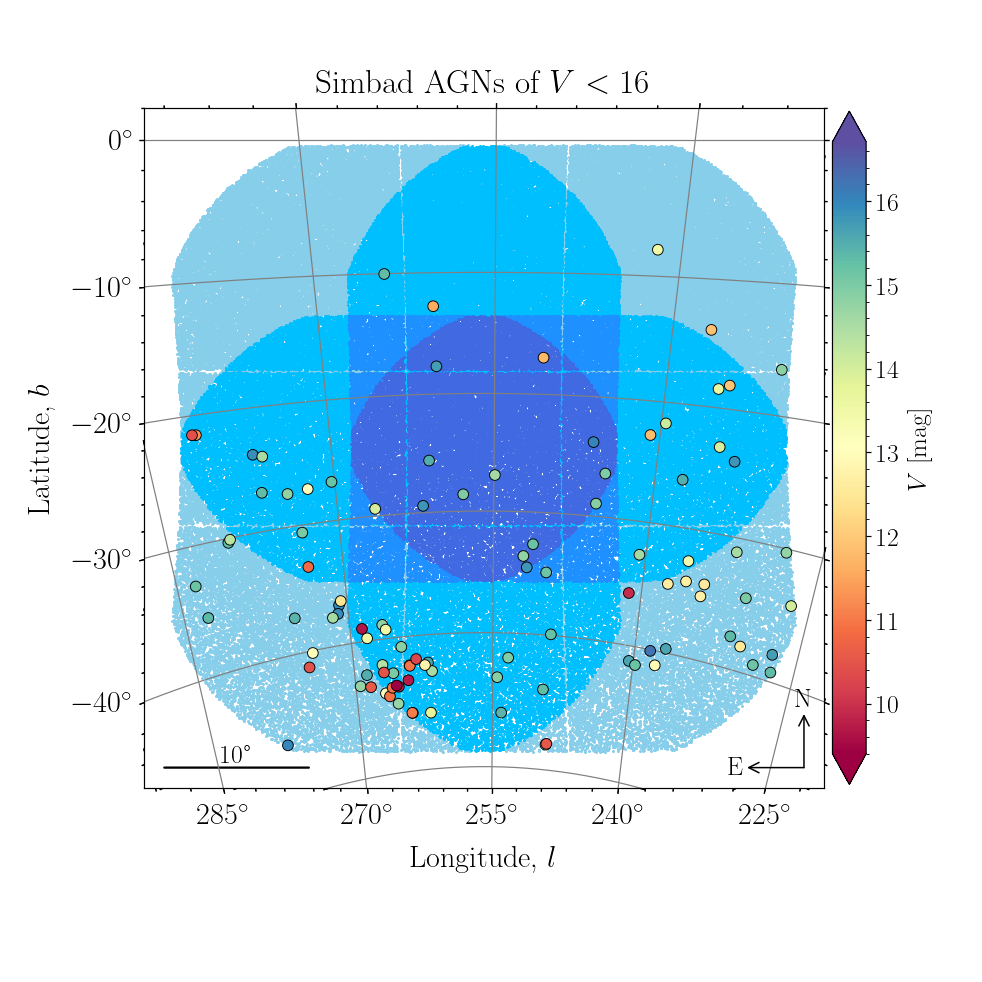

In [215]:
# Plot forbidden targets in LOPS2 
dx = df_simbad.sort_values(by='Vmag', ascending=False)
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', ncamStars=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Vmag, 
    clabel=r'$V$ [mag]', s=200, lw=0.6, 
    figsize=(9,9), title=r'Simbad AGNs of $V < 16$'
);

### Load AGN catalogue of Jannsen+2026

In [220]:
# Load Plato AGN catalogue (Jannsen+2026)
ds = pd.read_feather(idir / 'starcat_PlatoCS_QSO_LOPS2_targets.ftr')
ds['source_gaia'] = [f'Gaia DR3 {i}' for i in ds.source_gaia_dr3]
ds = df.rename(columns={'source_gaia_dr3':'gaiaDR3'})

# Limited magnitude cut and sort after magnitude
df_agn = ds[ds.Gmag < 17.6].sort_values(by=['Gmag'])

# Remove heavily contaminated sources
df_agn = df_agn[df_agn.SPR < 0.05]

# Convert units [ppm -> ppt]
df_agn.NSR /= 1e3

# Remove heavily contaminated sources
df_agn = df_agn[df_agn.NSR < 10]

# Correct Ncam visibility close to edges
df_agn.ncam.loc[df_agn[(df_agn.ncam == 12) & (df_agn.NSR > 8.4)].index] = 6
df_agn.ncam.loc[df_agn[(df_agn.ncam == 12) & (df_agn.Pmag < 16.5) & (df_agn.NSR > 3.5)].index] = 6
df_agn.ncam.loc[df_agn[(df_agn.ncam == 18) & (df_agn.Pmag < 16.5)].index] = 12

# Keep most import columns
df_agn = pd.DataFrame({
    'name'   : None,
    'gaiaDR3': df_agn.gaiaDR3,
    'otype'  : 'AGN',
    'ra'     : df_agn.ra,
    'dec'    : df_agn.dec,
    'Vmag'   : df_agn.Gmag, # NOTE
    'Pmag'   : df_agn.Pmag,
    'Gmag'   : df_agn.Gmag,
    'BP_RP'  : df_agn.BP_RP,
    'SPR'    : df_agn.SPR,
    'NSR'    : df_agn.NSR,
    'ncam'   : df_agn.ncam,
    'sizeDSS': None,
    'z'      : df_agn.z
})

# Add work from manual inspection
df_extra = pd.read_csv(gdir / 'source_catalogue_agn_cfp_v1_extra.csv')
df_extra.Target_ID = [np.int64(f'{i[9:]}') for i in df_extra.Target_ID]
for i in range(df_agn.shape[0]):
    if df_agn.gaiaDR3.iloc[i] in df_extra.Target_ID.tolist():
        dx = df_extra[df_extra.Target_ID == df_agn.gaiaDR3.iloc[i]]
        df_agn.name.iloc[i] = dx.name.iloc[0]
        df_agn.otype.iloc[i] = dx.otype.iloc[0]
        df_agn.sizeDSS.iloc[i] = dx.sizeDSS.iloc[0]

# Remove potential RR Lyrae
df_agn = df_agn[df_agn.otype != 'RRLyr']

# Show remaining targets
df_agn.gaiaDR3 = [f'Gaia DR3 {i}' for i in df_agn.gaiaDR3]
df_agn = df_agn.reset_index(drop=True)

# Add optye to missing sources
dex = df_agn[df_agn.otype.isna()].index
df_agn.otype.iloc[dex] = 'AGN'
df_agn.shape[0]

301

In [221]:
# Check number statistics of AGN types
for i in df_agn.otype.unique():
    print(f'{i} : {df_agn[df_agn.otype == i].shape[0]}')
df_agn.shape[0]

AGN : 230
QSO : 48
G : 6
BLL : 1
Sy1 : 3
Bla : 5
rG : 4
Blue : 4


301

<IPython.core.display.Javascript object>


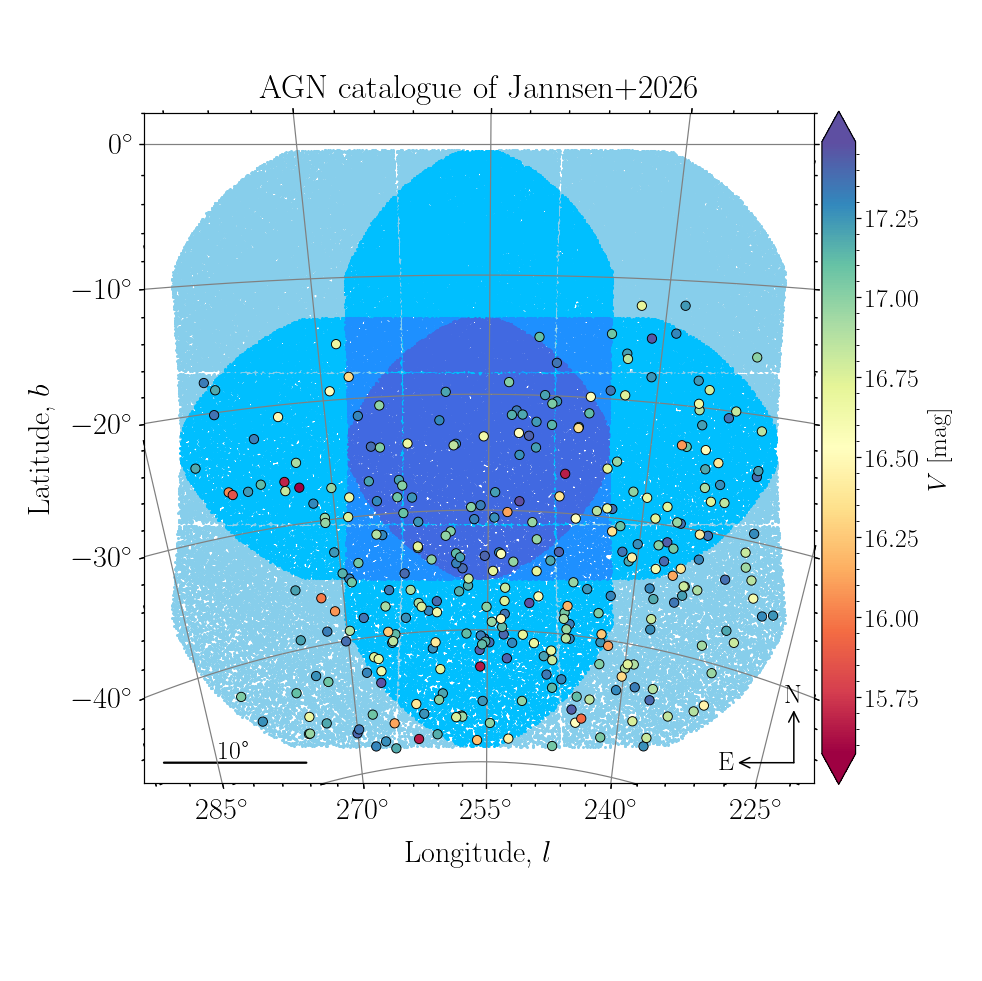

In [222]:
# Plot forbidden targets in LOPS2 
dx = df_agn.sort_values(by='Gmag', ascending=False)
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', ncamStars=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
    clabel=r'$V$ [mag]', s=150, lw=0.6, 
    title='AGN catalogue of Jannsen+2026',
    figsize=(9,9),
);

### Pictor A (ESO 252-18A)

Literature:
- [Smith+2023](https://iopscience.iop.org/article/10.3847/1538-4357/acff5c/pdf)

Technical notes:
- [CDS/DSS](https://portal.cds.unistra.fr/?target=Pictor%20A)
- N-CAM = 24
- Imagettes: YES (source extend 2-3 pixel)

In [223]:
# Download target from Simbad
df_PictorA = sq.simbadQuery('Pictor A', radius=15, maglim=19)

# Cross-match with LOPS2 sources
df_PictorA['gaiaDR3'] = [f'Gaia DR3 {i}' for i in df_PictorA.gaiaDR3]
ds_PictorA = dc[dc['gaiaDR3'].isin(df_PictorA['gaiaDR3'])].sort_values(by=['Pmag']).reset_index(drop=True)
ds_PictorA['ref'] = 'PictorA'
ds_PictorA

,PIC,gaiaDR3,ra,dec,Gmag,Pmag,PBmag,PRmag,ref
0,2699636000050,Gaia DR3 4799794011057558016,79.95718,-45.778848,16.842937,16.525375,16.887465,16.156663,PictorA


In [224]:
# Keep most import columns
df_PictorA = pd.DataFrame({
    'name'   : 'Pictor A',
    'gaiaDR3': df_PictorA.gaiaDR3,
    'otype'  : 'AGN',
    'ra'     : df_PictorA.ra,
    'dec'    : df_PictorA.dec,
    'Vmag'   : df_PictorA.Gmag, # NOTE
    'Pmag'   : df_PictorA.Pmag,
    'Gmag'   : df_PictorA.Gmag,
    'BP_RP'  : None,
    'SPR'    : 0,
    'NSR'    : 0,
    'ncam'   : 18,
    'sizeDSS': 20,
    'z'      : 0.0349747
})

In [48]:
# # Plot target in LOPS2 foorptint
# dx = df_PictorA.copy()
# fig, ax = pt.plotPlatoFOV(
#     'LOPS2', system='galactic', ncamStars=True,
#     raStars=dx.ra, decStars=dx.dec, c=dx.Gmag, 
#     clabel=r'$G$ [mag]', s=300, lw=0.5, ec='k',
#     figsize=(9,9)
# );

### Initial target list for CfP

In [228]:
# Combine catalogues
df1 = pd.concat([df_agn, df_simbad, df_PictorA])


# Remove duplicate Gaia DR3 IDs-
df1 = df1.drop_duplicates(subset='gaiaDR3').reset_index(drop=True)
df1.shape

(403, 14)

In [229]:
# Create CSV filt for CfP tool
dt0 = pd.DataFrame()
dt0['Target_ID']         = df1.gaiaDR3.tolist()
dt0['RA']                = df1.ra.tolist()
dt0['Dec']               = df1.dec.tolist()
dt0['Camera']            = 'normal'
dt0['ProcessingType']    = 'L_FX'
dt0['ObservationLength'] = 720
dt0['StartTime']         = None
dt0['EndTime']           = None

# Save catalogue
dt0.to_csv(gdir / 'source_catalogue_agn_cfp_v0.csv', index=False)
dt0

,Target_ID,RA,Dec,Camera,ProcessingType,ObservationLength,StartTime,EndTime
0,Gaia DR3 5477304692317531392,96.155124,-63.411827,normal,L_FX,720,None,None
1,Gaia DR3 4787832939454577536,67.655418,-48.923216,normal,L_FX,720,None,None
2,Gaia DR3 5284905413180301824,97.943273,-64.437557,normal,L_FX,720,None,None
3,Gaia DR3 2882337747595526528,90.061215,-41.091122,normal,L_FX,720,None,None
4,Gaia DR3 4828236384002699520,57.747604,-52.676254,normal,L_FX,720,None,None
...,...,...,...,...,...,...,...,...
398,Gaia DR3 4681746869284665984,63.017833,-58.557000,normal,L_FX,720,None,None
399,Gaia DR3 4775726904115785984,69.332917,-55.923003,normal,L_FX,720,None,None
400,Gaia DR3 4654782446138047104,71.310708,-71.014342,normal,L_FX,720,None,None
401,Gaia DR3 5574700596240225920,93.059133,-38.773150,normal,L_FX,720,None,None


### Fix and remove forbidden targets

In [230]:
# Load duplication report form CfP tool
dt0_dup = pd.read_csv(gdir / 'CfPtools_duplication_report.csv')
dt0_dup

,Target_ID,isPrimeSampleProximityFlag,isP1SampleProximityFlag,isP2SampleProximityFlag,isP4SampleProximityFlag,isP5SampleProximityFlag,isFgPICProximityFlag,isScvPICProximityFlag,isCPICProximityFlag
0,Gaia DR3 5477304692317531392,1,1,1,0,0,0,0,2
1,Gaia DR3 4787832939454577536,0,0,0,0,0,0,0,0
2,Gaia DR3 5284905413180301824,0,0,0,0,0,0,0,0
3,Gaia DR3 2882337747595526528,0,0,0,0,1,0,0,0
4,Gaia DR3 4828236384002699520,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
398,Gaia DR3 4681746869284665984,0,0,0,0,0,0,0,0
399,Gaia DR3 4775726904115785984,0,0,0,0,0,0,0,0
400,Gaia DR3 4654782446138047104,0,1,0,1,1,0,0,2
401,Gaia DR3 5574700596240225920,0,0,0,0,0,0,0,0


In [231]:
dex = []
dx = dt0_dup
for i in range(dx.shape[0]):
    dx0 = dx.iloc[i]
    count  = dx0.isPrimeSampleProximityFlag
    count += dx0.isP1SampleProximityFlag
    count += dx0.isP2SampleProximityFlag
    count += dx0.isP4SampleProximityFlag
    count += dx0.isP5SampleProximityFlag
    count += dx0.isFgPICProximityFlag
    count += dx0.isScvPICProximityFlag
    count += dx0.isCPICProximityFlag
    if count > 0:
        dex.append(i)
dex = np.array(dex)

In [232]:
# Forbidden targets
dt0.iloc[dex]

,Target_ID,RA,Dec,Camera,ProcessingType,ObservationLength,StartTime,EndTime
0,Gaia DR3 5477304692317531392,96.155124,-63.411827,normal,L_FX,720,None,None
3,Gaia DR3 2882337747595526528,90.061215,-41.091122,normal,L_FX,720,None,None
7,Gaia DR3 4841167396659799808,63.810269,-40.394754,normal,L_FX,720,None,None
8,Gaia DR3 4665633973057748096,73.566465,-61.274044,normal,L_FX,720,None,None
9,Gaia DR3 2890998291450368896,90.809341,-31.179016,normal,L_FX,720,None,None
...,...,...,...,...,...,...,...,...
368,Gaia DR3 4774591246042006016,72.236304,-57.659181,normal,L_FX,720,None,None
370,Gaia DR3 4778481661779060480,65.600258,-56.225625,normal,L_FX,720,None,None
382,Gaia DR3 5554574624305070976,91.648892,-47.498561,normal,L_FX,720,None,None
389,Gaia DR3 4800195161003160960,79.281762,-44.182103,normal,L_FX,720,None,None


<IPython.core.display.Javascript object>


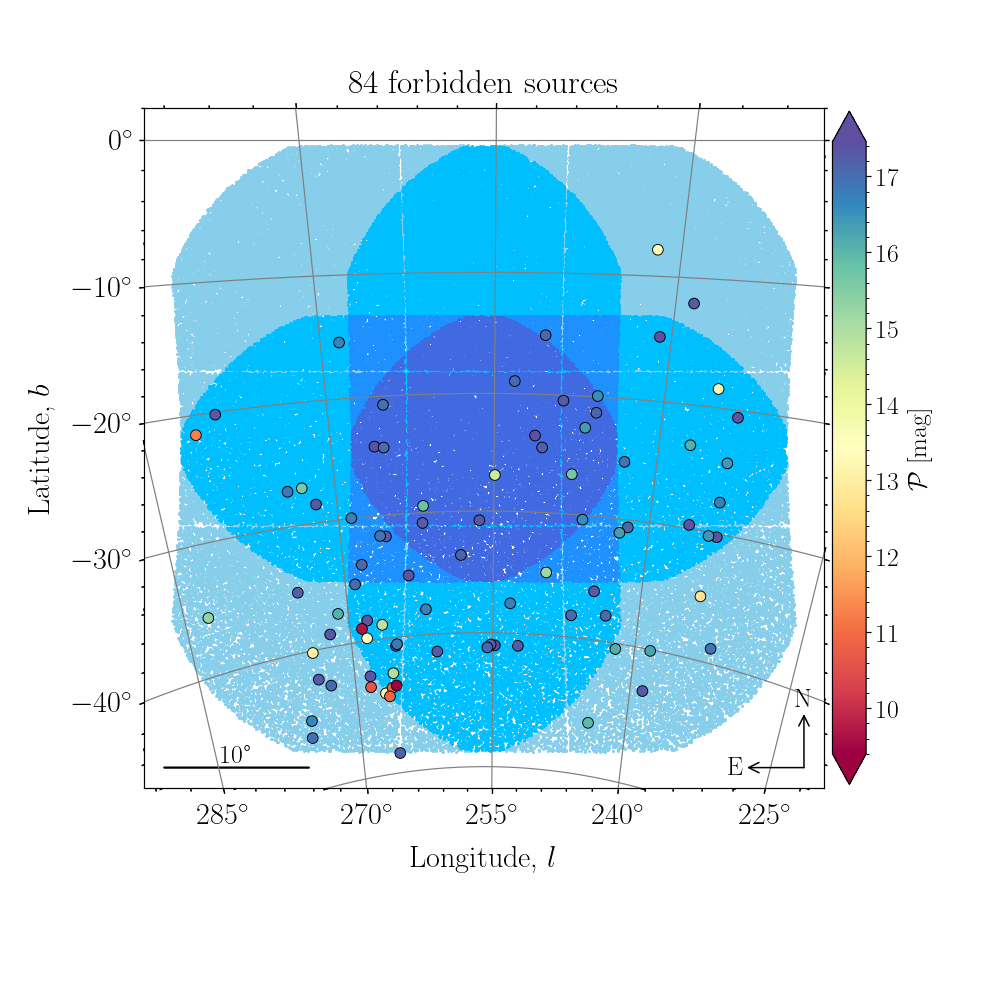

In [233]:
# Plot forbidden targets in LOPS2 
dx = df1.iloc[dex].sort_values(by='Pmag', ascending=False)
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', ncamStars=True, 
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
    clabel=r'$\mathcal{P}$ [mag]', s=200, lw=0.6, 
    figsize=(9,9), title=f'{dx.shape[0]} forbidden sources'
);

In [234]:
# We can upgrade the processing type if not a Prime sample star
dx0 = dx[dx.Pmag < 16].sort_values(by='Pmag', ascending=True)
dx0

,name,gaiaDR3,otype,ra,dec,Vmag,Pmag,Gmag,BP_RP,SPR,NSR,ncam,sizeDSS,z
320,NGC 1553,Gaia DR3 4778669369028919808,GiP,64.043621,-55.780019,9.400000,9.400000,9.400000,None,0.000000,None,12,300,0.004093
336,NGC 1672,Gaia DR3 4773934047325895168,SyG,71.4273,-59.247411,9.680000,9.680000,9.680000,None,0.000000,None,12,460,0.004464
301,NGC 1543,Gaia DR3 4682184230100236928,EmG,63.179871,-57.737869,10.600000,10.600000,10.600000,None,0.000000,None,6,200,0.003915
302,NGC 1533,Gaia DR3 4682608675948630656,EmG,62.465979,-56.118447,10.920000,10.920000,10.920000,None,0.000000,None,6,200,0.002647
303,NGC 1546,Gaia DR3 4778632260511770880,EmG,63.652258,-56.060811,10.920000,10.920000,10.920000,None,0.000000,None,12,180,0.004272
305,NGC 2434,Gaia DR3 2886589765219489792,EmG,113.713125,-69.284164,11.260000,11.260000,11.260000,None,0.000000,None,12,300,0.002488
308,NGC 1800,Gaia DR3 4867469845100665984,EmG,76.607237,-31.954225,12.700000,12.700000,12.700000,None,0.000000,None,6,40,0.059700
361,1RXS J042710.2-624712,Gaia DR3 4675802943784869248,Sy2,66.806392,-62.780658,13.000000,13.000000,13.000000,None,0.000000,None,6,30,0.018000
310,NGC 1536,Gaia DR3 2898562794012526976,EmG,62.749325,-56.480456,13.150000,13.150000,13.150000,None,0.000000,None,12,100,0.022365
363,MCG-05-18-002,Gaia DR3 5606511636595211392,Sy2,109.130025,-29.324689,13.520000,13.520000,13.520000,None,0.000000,None,6,65,0.005660


In [235]:
# Except for two stars we could upgrade
dt0_dup.iloc[dx0.index]

,Target_ID,isPrimeSampleProximityFlag,isP1SampleProximityFlag,isP2SampleProximityFlag,isP4SampleProximityFlag,isP5SampleProximityFlag,isFgPICProximityFlag,isScvPICProximityFlag,isCPICProximityFlag
320,Gaia DR3 4778669369028919808,1,0,0,0,1,0,0,2
336,Gaia DR3 4773934047325895168,0,0,0,0,1,0,0,0
301,Gaia DR3 4682184230100236928,0,0,0,1,0,0,0,0
302,Gaia DR3 4682608675948630656,0,0,0,0,1,0,0,0
303,Gaia DR3 4778632260511770880,0,0,0,0,1,0,1,0
305,Gaia DR3 2886589765219489792,0,0,0,0,1,0,0,0
308,Gaia DR3 4867469845100665984,0,0,0,0,1,0,0,0
361,Gaia DR3 4675802943784869248,0,0,0,0,1,0,0,2
310,Gaia DR3 2898562794012526976,0,0,0,0,1,0,1,0
363,Gaia DR3 5606511636595211392,0,0,0,0,0,0,1,0


In [236]:
# Remove forbidden targets
dt1 = dt0.drop(dex).reset_index(drop=True)
df2 = df1.drop(dex).reset_index(drop=True)

### Add imagettes for extended targets

In [275]:
dex = df2[(df2.sizeDSS > 15)].index
dt1.ProcessingType.iloc[dex] = 'F_IMA'
df2

,name,gaiaDR3,otype,ra,dec,Vmag,Pmag,Gmag,BP_RP,SPR,NSR,ncam,sizeDSS,z
0,QSO J0430-4855,Gaia DR3 4787832939454577536,QSO,67.655418,-48.923216,15.834169,15.651070,15.834169,0.576308,0.000054,1.644273,12,12.0,1.941430
1,6dFGS gJ063146.4-642615,Gaia DR3 5284905413180301824,G,97.943273,-64.437557,15.838762,15.679995,15.838762,0.488517,0.036189,1.501659,12,10.0,0.882349
2,[VV96] J035059.3-524035,Gaia DR3 4828236384002699520,QSO,57.747604,-52.676254,15.851448,15.658949,15.851448,0.611596,0.000771,2.351849,6,10.0,1.542538
3,2MASS J06330967-6834302,Gaia DR3 5279968331097175808,BLL,98.290282,-68.575052,16.002886,15.850229,16.002886,0.467201,0.001212,2.233288,12,8.0,0.739794
4,EC 05023-6231,Gaia DR3 4664566278549403392,AGN,75.710963,-62.461275,16.142601,15.998799,16.142601,0.43679,0.001870,3.181639,6,12.0,0.386029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,ESO 119-16,Gaia DR3 4665606996366566400,AG?,72.871125,-61.649944,14.580000,14.580000,14.580000,None,0.000000,None,6,300,0.003284
315,IC 2049,Gaia DR3 4681746869284665984,AG?,63.017833,-58.557,14.740000,14.740000,14.740000,None,0.000000,None,6,50,0.004902
316,ESO 157-44,Gaia DR3 4775726904115785984,AG?,69.332917,-55.923003,14.870000,14.870000,14.870000,None,0.000000,None,12,60,0.005370
317,LEDA 75555,Gaia DR3 5574700596240225920,AG?,93.059133,-38.77315,16.020000,16.020000,16.020000,None,0.000000,None,24,30,0.006000


In [289]:
dx = dt1.copy()
dx['Gmag'] = df2.Gmag 
dx1 = dx[dx.ProcessingType == 'L_FX'].sort_values(by=['Gmag'])
dx2 = dx[dx.ProcessingType == 'F_IMA'].sort_values(by=['Gmag'])
dx = pd.concat([dx1, dx2]).drop(columns=['Gmag']).reset_index(drop=True)
dx

,Target_ID,RA,Dec,Camera,ProcessingType,ObservationLength,StartTime,EndTime
0,Gaia DR3 4775331664045020160,66.502992,-57.200489,normal,L_FX,720,None,None
1,Gaia DR3 4756452052971526912,88.102092,-64.036319,normal,L_FX,720,None,None
2,Gaia DR3 4879352885736712192,70.836600,-28.347822,normal,L_FX,720,None,None
3,Gaia DR3 4814500219596967296,72.352908,-43.835822,normal,L_FX,720,None,None
4,Gaia DR3 4893164366689421696,70.343887,-27.138703,normal,L_FX,720,None,None
...,...,...,...,...,...,...,...,...
314,Gaia DR3 4780619627780461696,67.666800,-53.615456,normal,F_IMA,720,None,None
315,Gaia DR3 5505467789310281472,107.172867,-49.551750,normal,F_IMA,720,None,None
316,Gaia DR3 4799794011057558016,79.957175,-45.778847,normal,F_IMA,720,None,None
317,Gaia DR3 4761465310590509056,74.989900,-61.252706,normal,F_IMA,720,None,None


### Resubmission to CfP tool

In [290]:
# Save catalogue with forbidden targets removed
dx.to_csv(gdir / 'source_catalogue_agn_cfp_FINAL.csv', index=False)

In [239]:
df2.to_csv(ddir / 'table_galaxies_agn_proposal_v0.csv')

---
## 2. Plots for proposal
---

### Final target list

In [240]:
# Check number statistics of AGN types
for i in df2.otype.unique():
    print(f'{i} : {df2[df2.otype == i].shape[0]}')
df2.shape[0]

QSO : 48
G : 6
BLL : 7
AGN : 168
Sy1 : 22
Bla : 5
rG : 6
Blue : 4
EmG : 11
GiP : 6
GiG : 6
SyG : 1
Sy2 : 15
LIN : 2
AG? : 12


319

In [241]:
# Check for Pictor A
df2[df2.name == 'ESO 252-18A']

,name,gaiaDR3,otype,ra,dec,Vmag,Pmag,Gmag,BP_RP,SPR,NSR,ncam,sizeDSS,z
279,ESO 252-18A,Gaia DR3 4799794011057558016,Sy1,79.957175,-45.778847,15.77,15.77,15.77,None,0.0,None,18,18,0.034975


In [242]:
# Candidates as a function of contamination
print(
    df2[(df2.SPR > 0.01)].shape[0], 
    df2[(df2.SPR > 0.02)].shape[0], 
    df2[(df2.SPR > 0.03)].shape[0], 
    df2[(df2.SPR > 0.04)].shape[0],
)

70 37 22 9


In [243]:
# Candidates for imagettes req1
print(
    df2[(df2.SPR > 0.01) & (df2.Pmag < 16.0)].shape[0],
    df2[(df2.SPR > 0.01) & (df2.Pmag < 16.5)].shape[0],
    df2[(df2.SPR > 0.01) & (df2.Pmag < 17.0)].shape[0],
)

1 5 36


In [258]:
# Final statistics
print(
    df2.shape[0],
    df2[(df2.sizeDSS < 15)].shape[0],
    df2[(df2.sizeDSS < 15) & (df2.SPR < 0.01)].shape[0],
    df2[(df2.sizeDSS > 15)].shape[0],
)

319 239 173 69


### Plot redshift distribution

In [245]:
# # Seperate camera visibility
# mag = 'Gmag'
# dt = df2.copy()
# # dt = dt[dt[mag] < 15]
# dt06 = dt[dt.ncam ==  6]
# dt12 = dt[dt.ncam == 12]
# dt18 = dt[dt.ncam == 18]
# dt24 = dt[dt.ncam == 24]
# dt = dt.reset_index(drop=True)
# aa, lw, N = 0.2, 1.1, 30
# c = ['orangered', 'orange', 'limegreen', 'royalblue', 'k']

# # Plot histograms
# fig = plt.figure(figsize=(7,7))

# ax1 = plt.subplot(2, 1, 1)
# m_min, m_max = dt[mag].min(), dt[mag].max()
# # G_min, G_max = 15.5, 17.6
# ax1.hist(dt06[mag], bins=N, range=(m_min, m_max), histtype='step', ec=c[0], lw=lw, label='6')
# ax1.hist(dt12[mag], bins=N, range=(m_min, m_max), histtype='step', ec=c[1], lw=lw, label='12')
# ax1.hist(dt18[mag], bins=N, range=(m_min, m_max), histtype='step', ec=c[2], lw=lw, label='18')
# ax1.hist(dt24[mag], bins=N, range=(m_min, m_max), histtype='step', ec=c[3], lw=lw, label='24')
# ax1.hist(dt[mag],   bins=N, range=(m_min, m_max), histtype='stepfilled', ec=c[4], lw=lw, alpha=aa, label='All')
# ax1.set_xlabel(r'\textit{Gaia} magnitude, $G$')
# ax1.set_xlim(m_min, m_max)
# ax1.legend(loc='upper left', bbox_to_anchor=(-0.02, 1.25), ncols=5, fontsize=15)
# ax1.set_yscale('log')

# ax2 = plt.subplot(2, 1, 2)
# z_min, z_max = dt.z.min(), dt.z.max()
# ax2.hist(dt06.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[0], lw=lw)
# ax2.hist(dt12.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[1], lw=lw)
# ax2.hist(dt18.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[2], lw=lw)
# ax2.hist(dt24.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[3], lw=lw)
# ax2.hist(dt.z,   bins=N, range=(z_min, z_max), histtype='stepfilled', ec=c[4], lw=lw, alpha=aa)
# ax2.set_xlabel(r'\textit{Quaia} redshift, $z$')
# ax2.set_xlim(z_min, z_max)
# ax2.set_yscale('log')

# # Settings
# for ax in [ax1, ax2]:
#     ax.set_ylabel('Count')
#     ax.get_yaxis().set_label_coords(-0.07, 0.5)
# plt.tight_layout()

# # Save figure
# # fig.savefig(fdir / 'plot_agn_hist.png', bbox_inches='tight', dpi=300)

<IPython.core.display.Javascript object>


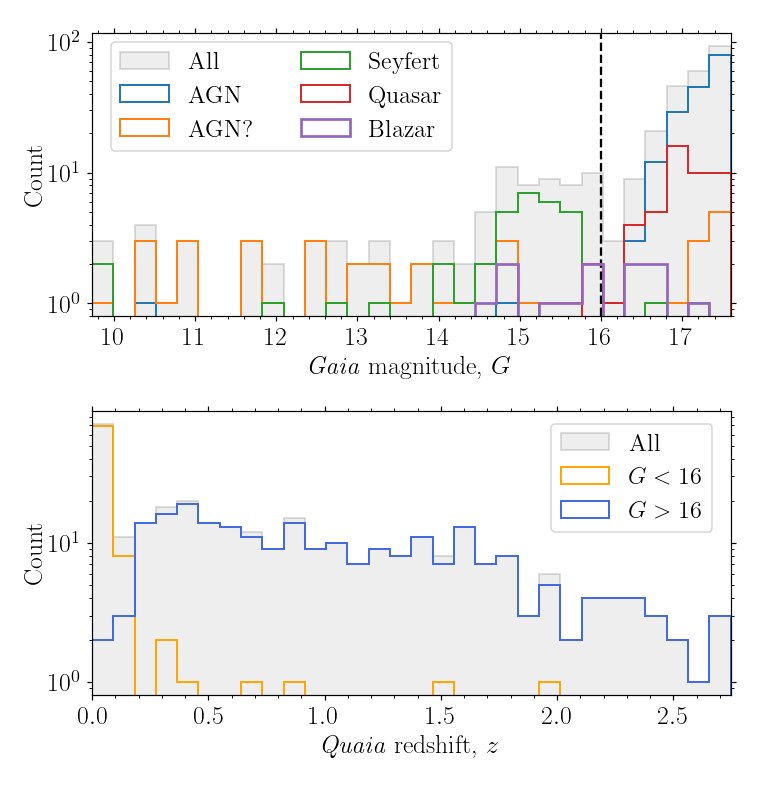

In [247]:
# Seperate camera visibility
c = ['orangered', 'orange', 'limegreen', 'royalblue', 'k']
aa, lw, N = 0.13, 1.3, 30
mag = 'Gmag'
dt = df2.copy()
dt_bright = dt[dt[mag] < 16]
dt_faint  = dt[dt[mag] > 16]

# Plot histograms
fig = plt.figure(figsize=(7,7.2))

# Plot Gmag distribution
ax1 = plt.subplot(2, 1, 1)
m_min, m_max = dt[mag].min(), dt[mag].max()
ax1.hist(dt[mag], bins=N, range=(m_min, m_max), histtype='stepfilled', color='gray', ec='k', lw=lw, alpha=aa, label='All')
ax1.axvline(16, c='k', ls='--', lw=1.5)
# AG
dx = dt[(dt.otype=='AGN') | (dt.otype=='LIN') | (dt.otype=='rG')]
ax1.hist(dx[mag], bins=N, range=(m_min, m_max), histtype='step', lw=lw, label='AGN')
# AG?
dx = dt[(dt.otype=='AG?') | (dt.otype=='EmG') | (dt.otype=='Blue') |
        (dt.otype=='G') | (dt.otype=='GiG') | (dt.otype=='GiP')]
ax1.hist(dx[mag], bins=N, range=(m_min, m_max), histtype='step', lw=lw, label='AGN?')
# SyG
dx = dt[(dt.otype=='SyG') | (dt.otype=='Sy1') | (dt.otype=='Sy2')]
ax1.hist(dx[mag], bins=N, range=(m_min, m_max), histtype='step', lw=lw, label='Seyfert')
# QSO
dx = dt[(dt.otype=='QSO')]
ax1.hist(dx[mag], bins=N, range=(m_min, m_max), histtype='step', lw=lw, label='Quasar')
# Bla
dx = dt[(dt.otype=='Bla') | (dt.otype=='BLL')]
ax1.hist(dx[mag], bins=N, range=(m_min, m_max), histtype='step', lw=lw+0.5, label='Blazar')
#Settings
ax1.legend(loc='upper left', bbox_to_anchor=(0.01, 1.01), ncols=2, fontsize=16)
ax1.set_xlabel(r'\textit{Gaia} magnitude, $G$')
ax1.set_xlim(m_min, m_max)
ax1.set_yscale('log')

# Plot z distribution
ax2 = plt.subplot(2, 1, 2)
z_min, z_max = dt.z.min(), dt.z.max()
ax2.hist(dt.z, bins=N, range=(z_min, z_max), histtype='stepfilled', color='gray', ec='k', lw=lw, alpha=aa, label='All')
ax2.hist(dt_bright.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[1], lw=lw, label=r'$G < 16$')
ax2.hist(dt_faint.z,  bins=N, range=(z_min, z_max), histtype='step', ec=c[3], lw=lw, label=r'$G > 16$')
# Settings
ax2.set_xlabel(r'\textit{Quaia} redshift, $z$')
ax2.set_xlim(z_min, z_max)
ax2.set_yscale('log')
ax2.legend(loc='upper left', bbox_to_anchor=(0.7, 1), ncols=1, fontsize=16)

# Common settings
for ax in [ax1, ax2]:
    ax.set_ylabel('Count')
    ax.get_yaxis().set_label_coords(-0.07, 0.5)
plt.tight_layout()

# Save figure
fig.savefig(fdir / 'plot_agn_hist.png', bbox_inches='tight', dpi=300)

In [201]:
# # Seperate camera visibility
# c = ['orangered', 'orange', 'limegreen', 'royalblue', 'k']
# aa, lw, N = 0.13, 1.3, 30
# mag = 'Gmag'
# dt = df2.copy()
# dt_bright = dt[dt[mag] < 16]
# dt_faint  = dt[dt[mag] > 16]

# # Plot histograms
# fig = plt.figure(figsize=(7,7.25))

# # Plot Gmag distribution
# ax1 = plt.subplot(2, 1, 1)
# m_min, m_max = dt[mag].min(), dt[mag].max()
# ax1.hist(dt[mag], bins=N, range=(m_min, m_max), histtype='stepfilled', color='gray', ec='k', lw=lw, alpha=aa, label='All')
# ax1.axvline(16, c='k', ls='--', lw=1.5)

# dx = dt[(dt.otype=='AGN') | (dt.otype=='LIN') | (dt.otype=='rG')]
# ax1.hist(dx[mag], bins=N, range=(m_min, m_max), histtype='step', lw=lw, label='AGN')

# dx = dt[(dt.otype=='AGN') | (dt.otype=='LIN') | (dt.otype=='rG') |
#         (dt.otype=='AG?') | (dt.otype=='G') | (dt.otype=='GiG') | (dt.otype=='GiP')]
# ax1.hist(dx[mag], bins=N, range=(m_min, m_max), histtype='step', lw=lw, label='AG?')

# dx = dt[(dt.otype=='AGN') | (dt.otype=='LIN') | (dt.otype=='rG') |
#         (dt.otype=='AG?') | (dt.otype=='G') | (dt.otype=='GiG') | (dt.otype=='GiP') |
#         (dt.otype=='EmG') | (dt.otype=='Blue')
#        ]
# ax1.hist(dx[mag], bins=N, range=(m_min, m_max), histtype='step', lw=lw, label='EmG')

# # dx = dt[(dt.otype=='SyG') | (dt.otype=='Sy1') | (dt.otype=='Sy2')]
# # ax1.hist(dx[mag], bins=N, range=(m_min, m_max), histtype='step', lw=lw, label='SyG')

# # dx = dt[(dt.otype=='QSO')]
# # ax1.hist(dx[mag], bins=N, range=(m_min, m_max), histtype='step', lw=lw, label='QSO')

# # dx = dt[(dt.otype=='Bla') | (dt.otype=='BLL')]
# # ax1.hist(dx[mag], bins=N, range=(m_min, m_max), histtype='step', lw=lw, label='Bla')

# ax1.legend(loc='upper left', bbox_to_anchor=(0.01, 1.01), ncols=2, fontsize=16)
# ax1.set_xlabel(r'\textit{Gaia} magnitude, $G$')
# ax1.set_xlim(m_min, m_max)
# ax1.set_yscale('log')

# # Plot z distribution
# ax2 = plt.subplot(2, 1, 2)
# z_min, z_max = dt.z.min(), dt.z.max()
# ax2.hist(dt.z, bins=N, range=(z_min, z_max), histtype='stepfilled', color='gray', ec='k', lw=lw, alpha=aa, label='All')
# ax2.hist(dt_bright.z, bins=N, range=(z_min, z_max), histtype='step', ec=c[1], lw=lw, label=r'$G < 16$')
# ax2.hist(dt_faint.z,  bins=N, range=(z_min, z_max), histtype='step', ec=c[3], lw=lw, label=r'$G > 16$')
# ax2.set_xlabel(r'\textit{Quaia} redshift, $z$')
# ax2.set_xlim(z_min, z_max)
# ax2.set_yscale('log')
# ax2.legend(loc='upper left', bbox_to_anchor=(0.7, 1), ncols=1, fontsize=16)

# # Settings
# for ax in [ax1, ax2]:
#     ax.set_ylabel('Count')
#     ax.get_yaxis().set_label_coords(-0.07, 0.5)
# plt.tight_layout()

# # Save figure
# # fig.savefig(fdir / 'plot_agn_hist.png', bbox_inches='tight', dpi=300)

### Plot targets in LOPS2 footprint

<IPython.core.display.Javascript object>


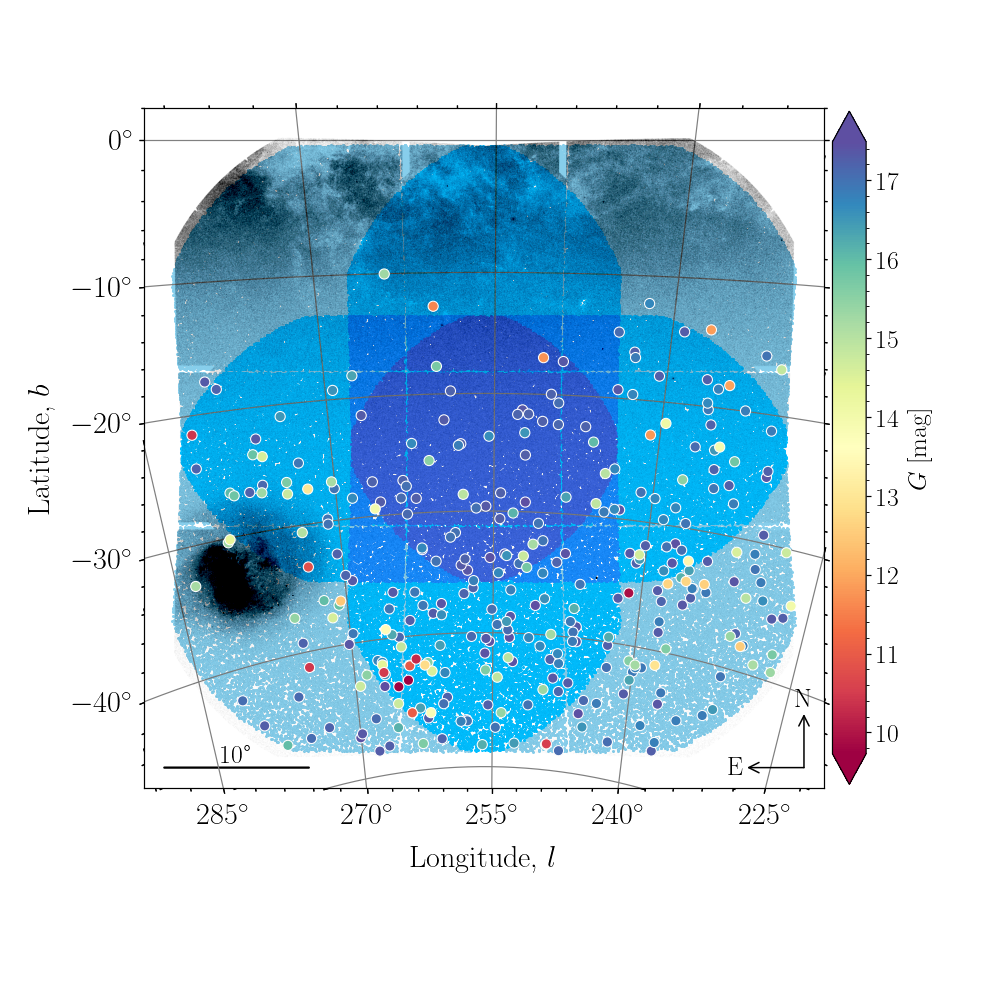

In [248]:
# Plot catalogue within LOPS2 foorptint
dx = df2.sort_values(by='Gmag', ascending=False)
fig, ax = pt.plotPlatoFOV(
    'LOPS2', system='galactic', ncamStars=True, showGalactic=True,
    raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, s=180, lw=0.7, ec='w',
    clabel=r'$G$ [mag]', cmap='Spectral',#'PiYG', 
    figsize=(9,9)
)
fig.savefig(fdir / 'plot_agn_sky.png', bbox_inches='tight', dpi=300)

### Plot NSR vs. magnitude (v.0)

In [5]:
# Bright NSR estimates from Jannsen+2025
df_nsr_bright = pd.read_feather('/lhome/nicholas/software/workdir/mocka/simulations/nsr/nsr_per_star_BOL.ftr')
df_nsr_bright = df_nsr_bright.drop(columns=['index', 'ID','rOA'])
 # Account for "as required" -> "as expected" update in Jannsen+2026
df_nsr_bright.NSR /= 1.1

# Faint NSR estimates from Jannse+2026
dn = pd.read_feather(idir / 'starcat_PlatoCS_QSO_LOPN1_targets.ftr')
ds = pd.read_feather(idir / 'starcat_PlatoCS_QSO_LOPS2_targets.ftr')
df_nsr_faint = pd.concat([dn, ds]).sort_values(by=['ncam', 'Pmag']).reset_index(drop=True)
df_nsr_faint = pd.DataFrame({
    'mag': df_nsr_faint.Pmag,
    'ncon': df_nsr_faint.ncon,
    'SPR': df_nsr_faint.SPR,
    'ncam': df_nsr_faint.ncam,
    'NSR': df_nsr_faint.NSR
})
df_nsr = pd.concat([df_nsr_bright, df_nsr_faint])

<IPython.core.display.Javascript object>


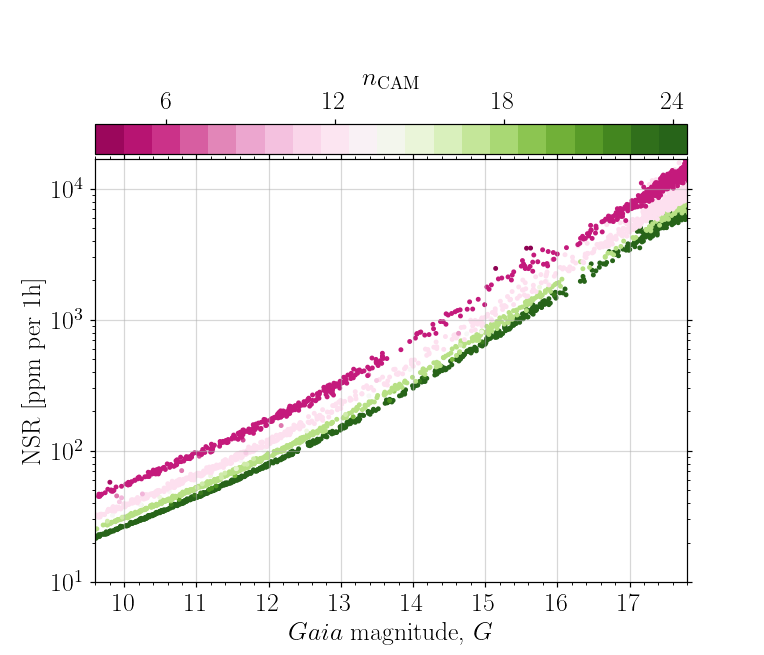

FileNotFoundError: [Errno 2] No such file or directory: '/lhome/nicholas/Nextcloud/latex/platoGOproposalAGN/plot_nsr_vs_mag_new.png'

In [6]:
# Plot mission level NSR for LOPS2
cmap = 'PiYG'
col = 'ncam'
lim = 0.01
xmin, xmax = 9.6, 17.8
ymin, ymax = 1e1, 2e4

dx = df_nsr.copy().sort_values(by=[col], ascending=False)
dx = dx[dx.SPR < lim]

fig, ax = plt.subplots(1, 1, figsize=(7,6))

# NSR vs. mag plot
im = ax.scatter(dx.mag, dx.NSR, s=5, alpha=1, zorder=1, c=dx[col], cmap=cmap)
cbins = np.arange(dx[col].min(), dx[col].max()+2, 1)
ticks = np.array([1, 6, 12, 18, 24]) + 0.5 
norm  = pt.discretizeColorbar(cbins=cbins, cmap=cmap)
cb = plt.colorbar(im, pad=0.01, spacing='proportional', location='top',
                  ticks=ticks, boundaries=cbins, format='%1i')
cb.set_label(r'$n_{\rm CAM}$')
cb.minorticks_off()
ax.set_xlabel(r'$Gaia$ magnitude, $G$')
ax.set_ylabel('NSR [ppm per 1h]')
ax.set_yscale('log')
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, 1.7e4)
ax.grid(alpha=0.5)
from matplotlib.ticker import MaxNLocator
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=10))

# Plot light curve
bins = 35
ax2 = ax.twinx().twiny()
dx0 = df2.copy()
ax2.hist(dx0.Pmag, bins=bins, range=(8,18), histtype='stepfilled', ec='k', lw=1, alpha=0.2, zorder=0)
dx1 = dx0[(dx0.sizeDSS > 15)] 
ax2.hist(dx1.Pmag, bins=bins, range=(8,18), histtype='step', ec='purple', lw=1)
ax2.text(18.35, 45, 'Counts', c='k', fontsize=18, rotation=90)
ax2.set_xlim(xmin, xmax)
ax2.set_ylim(0, 100)
ax2.set_xticks([])
# ax2.set_yscale('log')

# Save figure
fig.savefig(fdir / 'plot_nsr_vs_mag.png', bbox_inches='tight', dpi=300)

In [29]:
# # Plot mission level NSR for LOPS2
# cmap = 'Spectral'
# col = 'ncam'
# lim = 0.01
# xmin, xmax = 7.4, 18
# ymin, ymax = 7e0, 3e4

# dx = df_nsr.copy().sort_values(by=[col], ascending=False)
# dx = dx[dx.SPR < lim]

# fig, ax = plt.subplots(1, 1, figsize=(7,6))

# # NSR vs. mag plot
# im = ax.scatter(dx.mag, dx.NSR, s=5, alpha=1, zorder=1, c=dx[col], cmap=cmap)
# cbins = np.arange(dx[col].min(), dx[col].max()+2, 1)
# ticks = np.array([1, 6, 12, 18, 24]) + 0.5 
# norm  = pt.discretizeColorbar(cbins=cbins, cmap=cmap)
# cb = plt.colorbar(im, pad=0.01, spacing='proportional', location='top',
#                   ticks=ticks, boundaries=cbins, format='%1i')
# cb.set_label(r'$n_{\rm CAM}$')
# cb.minorticks_off()
# ax.set_xlabel(r'$Plato$ magnitude, $\mathcal{P}$')
# ax.set_ylabel('NSR [ppm per 1h]')
# ax.set_yscale('log')
# ax.set_xlim(xmin, xmax)
# ax.set_ylim(ymin, ymax)
# ax.grid(alpha=0.5)
# from matplotlib.ticker import MaxNLocator
# plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=10))

# ax.axvline(8, c='k', ls='--', lw=1.5)
# ax.axvline(17, c='k', ls='--', lw=1.5)

# # Save figure
# fig.savefig(fdir / 'plot_nsr_vs_mag_new.png', bbox_inches='tight', dpi=300)

### Plot NSR vs. Mag (v.1)

<IPython.core.display.Javascript object>


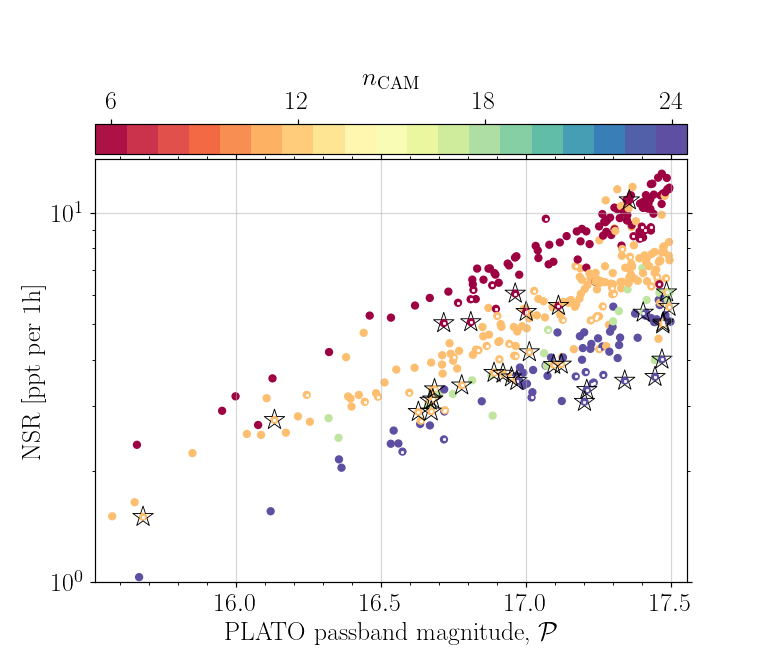

(1.0, 14.0)

In [18]:
# Plot NSR vs. magnitude (show different observing modes)
fig, ax = plt.subplots(1, 1, figsize=(7,6))

# Plot all targets
dx = df0.copy()
mag = dx.Pmag
col = 'ncam'
cmap = 'Spectral'
im0 = ax.scatter(mag, dx.NSR, s=20, alpha=1, zorder=1, c=dx[col], cmap=cmap)

# Plot contaminated targets
dx0 = df1[df1.SPR > 0.01]
ax.scatter(dx0.Pmag, dx0.NSR, s=10, marker='.', facecolors='w', edgecolors='w', lw=0.5)

# Plot targets requested for imagettes
dx1 = df1[(df1.SPR > 0.028) & (df1.SizeDSS < 15)]
ax.scatter(dx1.Pmag, dx1.NSR, s=200, marker='*', facecolors='none', edgecolors='k', lw=0.6)
dx2 = df1[(df1.SPR < 0.028) & (df1.SizeDSS > 15)]
ax.scatter(dx2.Pmag, dx2.NSR, s=200, marker='*', facecolors='none', edgecolors='k', lw=0.6)
# Check objects
# dx3 = df1[(df1.Object == 'Quasar')]
# ax.scatter(dx3.Pmag, dx3.NSR, s=200, marker='s', facecolors='none', edgecolors='k', lw=0.6)
# Identify N-CAM outliers close to edges
# dx3 = df1[(df1.ncam == 12) & (df1.Pmag < 16.5) & (df1.NSR > 3.5)]
# ax.scatter(dx3.Pmag, dx3.NSR, s=200, marker='s', facecolors='none', edgecolors='k', lw=0.6)

# Colorbar
cbins = np.arange(dx[col].min(), dx[col].max()+2, 1)
ticks = np.array([1, 6, 12, 18, 24]) + 0.5 
norm  = pt.discretizeColorbar(cbins=cbins, cmap=cmap)
cb = plt.colorbar(im0, pad=0.01, spacing='proportional', location='top',
                  ticks=ticks, boundaries=cbins, format='%1i')
cb.set_label(r'$n_{\rm CAM}$')
cb.minorticks_off()

# Settings
ax.set_xlabel('PLATO passband magnitude, $\mathcal{P}$')
ax.set_ylabel('NSR [ppt per 1h]')
dx = (mag.max() - mag.min()) * 0.03
ax.set_xlim(mag.min()-dx, mag.max()+dx)
ax.set_yscale('log')
ax.grid(alpha=0.5)
ax.set_ylim(1e0, 1.4e1)

# Save figure
# fig.savefig(fdir / 'plot_nsr_vs_mag.png', bbox_inches='tight', dpi=300)

In [154]:
# dx = df1[(df1.ncam == 12) & (df1.NSR > 8.4)]
# dx = df1[(df1.ncam == 12) & (df1.Pmag < 16.5) & (df1.NSR > 3.5)]
# fig, ax = pt.plotPlatoFOV(
#     'LOPS2', system='galactic', ncamStars=True, 
#     raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
#     clabel=r'$\mathcal{P}$ [mag]', s=200, lw=0.6, 
#     figsize=(9,9), title='Forbidden sources'
# )